In [2]:
!pip install numpy==2.2.0
!pip install panda==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement panda==2.2.3 (from versions: 0.1.1, 0.1.2, 0.1.3, 0.1.4, 0.1.5, 0.3.1)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for panda==2.2.3



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pdiddy

## Load the data
The dataset we will use resides at the following URL. You can use the URL directly with the Pandas library to load the dataset.

In [4]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv'
df = pdiddy.read_csv(url)
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
882,2014,PORSCHE,911 TURBO,MINICOMPACT,3.8,6,AM7,Z,13.7,9.6,11.9,24,274
576,2014,JEEP,CHEROKEE TRAILHAWK 4X4,SUV - SMALL,3.2,6,A9,X,13.4,9.5,11.6,24,267
577,2014,JEEP,COMPASS,SUV - SMALL,2.0,4,A6,X,11.1,8.3,9.8,29,225
589,2014,JEEP,PATRIOT,SUV - SMALL,2.0,4,A6,X,11.1,8.3,9.8,29,225
703,2014,MAZDA,MAZDA3 4-DOOR,COMPACT,2.0,4,AS6,X,7.9,5.7,6.9,41,159


## Understand the data

### `FuelConsumption.csv`:
We will use a fuel consumption dataset, **`FuelConsumption.csv`**, which contains model-specific fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada. [Dataset source](http://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64).

- **MODEL YEAR** e.g. 2014
- **MAKE** e.g. VOLVO
- **MODEL** e.g. S60 AWD
- **VEHICLE CLASS** e.g. COMPACT
- **ENGINE SIZE** e.g. 3.0
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. AS6
- **FUEL TYPE** e.g. Z
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 13.2
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 9.5
- **FUEL CONSUMPTION COMBINED (L/100 km)** e.g. 11.5
- **FUEL CONSUMPTION COMBINED MPG (MPG)** e.g. 25
- **CO2 EMISSIONS (g/km)** e.g. 182 

We will create a simple linear regression model from one of these features to predict CO2 emissions of unobserved cars based on that feature.

### Explore the data
First, We consider a statistical summary of the data.

In [5]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


From the data, we can see that most cars (about 75%) have a fuel efficiency between 11 and 31 MPG. However, one car shows a value of 60 MPG, which is much higher than the rest. This could either be a valid reading for a highly efficient or hybrid vehicle, or it might be an outlier or a data entry error.

MODELYEAR has 0 standard deviation, and thus has no interesting information content.

#### Select features
We will select a few features that might be indicative of CO2 emission to explore more.

In [6]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
cdf.sample(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
779,6.2,8,15.7,361
122,4.4,8,14.7,338
634,5.2,10,15.7,361
262,5.3,8,18.4,294
1011,3.5,6,11.3,260
646,5.0,8,15.0,345
523,1.6,4,8.0,184
50,5.2,10,15.4,354
440,5.3,8,21.5,344


#### Visualize features
Consider the histograms for each of these features.

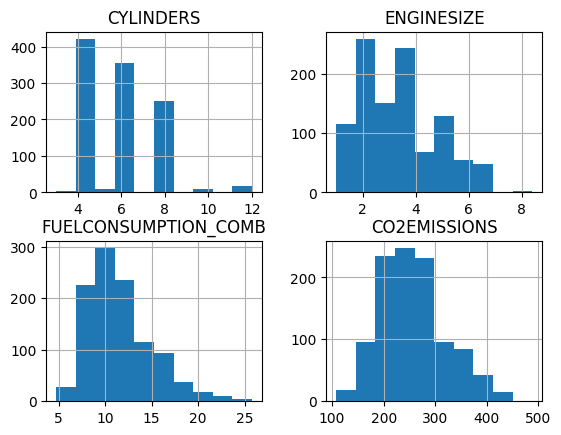

In [7]:
vis = cdf[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
vis.hist()
plt.show()

As we can see, most engines have 4, 6, or 8 cylinders, and engine sizes between 2 and 4 liters.  
As you might expect, combined fuel consumption and CO2 emission have very similar distributions.  
Let's display some scatter plots of these features against the CO2 emissions, to see how linear their relationships are.

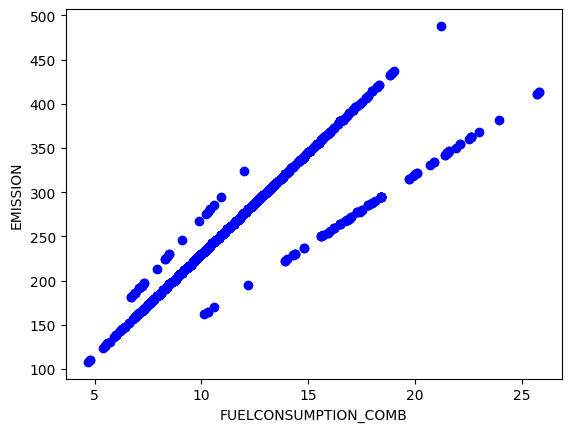

In [8]:
plt.scatter(cdf.FUELCONSUMPTION_COMB,cdf.CO2EMISSIONS, color ='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("EMISSION")
plt.show()

This is an informative result. Three car groups each have a strong linear relationship between their combined fuel consumption and their CO2 emissions. 
Their intercepts are similar, while they noticeably differ in their slopes.

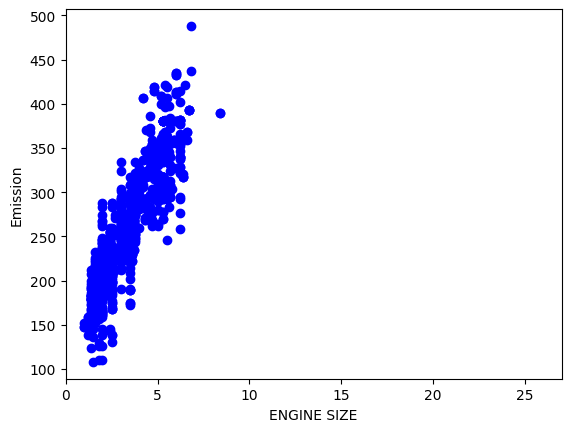

In [9]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color = 'blue')
plt.xlabel("ENGINE SIZE")
plt.ylabel("Emission")
plt.xlim(0,27)
plt.show()

Although the relationship between engine size and CO2 emission is quite linear, we can see that their correlation is weaker than that for each of the three fuel consumption groups. Notice that the x-axis range has been expanded to make the two plots more comparable.

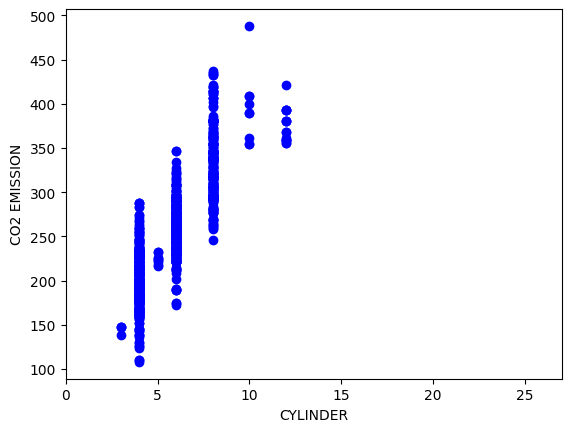

In [10]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color = 'blue')
plt.xlabel('CYLINDER')
plt.ylabel("CO2 EMISSION")
plt.xlim(0,27)
plt.show()

### Extract the input feature and labels from the dataset
Although perhaps not necessarily the ideal choice of input feature, for illustration purposes, we will use engine size to predict CO2 emission with a linear regression model.  
We will begin the process by extracting the input feature and target output variables, X and y, from the dataset.

In [11]:
X = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

#### Create train and test datasets
Next, we will split the dataset into mutually exclusive training and testing sets. We will train a simple linear regression model on the training set and estimate its ability to generalize to unseen data by using it to make predictions on the unseen testing data. 

Since the outcome of each data point is part of the testing data, you have a means of evaluating the out-of-sample accuracy of your model.

Now, we will randomly split the data into train and test sets, using 80% of the dataset for training and reserving the remaining 20% for testing. Which fraction to use here mostly depends on the size of your data, but typical testing sizes range from 20% to 30%. The smaller the data, the larger your training set needs to be because it's easier to find spurious patterns in smaller data. The downside is that the evaluation of generalizability will have less reliability. Bigger is better when it comes to data.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

The outputs are one-dimensional NumPy arrays or vectors.

In [13]:
type(X_train), np.shape(X_train), np.shape(X_train)

(numpy.ndarray, (853,), (853,))

### Build a simple linear regression model

We'll use scikit-learn to build our model as follows.

In [14]:
from sklearn import linear_model

#create a model object
regressor = linear_model.LinearRegression()

# we will train the model on the training data
#X_train is a 10D array but sklearn models expect a 2D array as input for the training data, with shape (n_observations, n_features)
#So we need to reshape it. We can let it inder the number of observations using '-1'
regressor.fit(X_train.reshape(-1,1), y_train)

#print the coefficients
print('Coefficients: ', regressor.coef_[0]) # with simple linear regression there is only one coefficients, here we extract it from the 1 by 1 array.
print('Intercept: ', regressor.intercept_)

Coefficients:  38.992978724434074
Intercept:  126.28970217408721


Here, __Coefficient__ and __Intercept__ are the regression parameters determined by the model.  
They define the slope and intercept of the 'best-fit' line to the training data. 

### __Visualize model outputs__

You can visualize the goodness-of-fit of the model to the training data by plotting the fitted line over the data.

The regression model is the line given by y = intercept + coefficient * x.

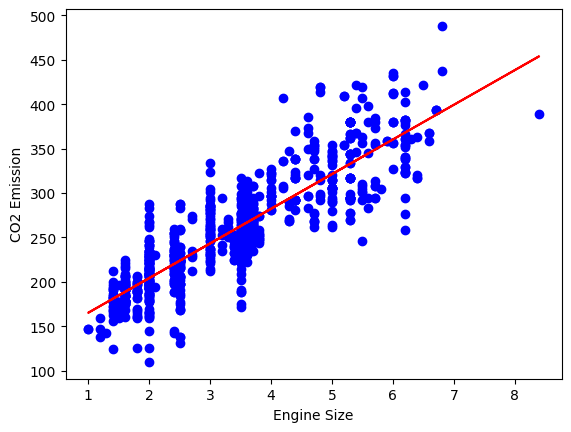

In [15]:
plt.scatter(X_train,y_train, color = 'blue')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r')
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emission")
plt.show()

#### Model evaluation
You can compare the actual values and predicted values to calculate the accuracy of a regression model. Evaluation metrics play a key role in the development of a model, as they provide insight into areas that require improvement.

There are different model evaluation metrics, let's use MSE here to calculate the accuracy of our model based on the test set: 
* __Mean Absolute Error:__ It is the mean of the absolute value of the errors. This is the easiest of the metrics to understand since it’s just an average error.

* __Mean Squared Error (MSE):__ MSE is the mean of the squared error. In fact, it's the metric used by the model to find the best fit line, and for that reason, it is also called the residual sum of squares.

* __Root Mean Squared Error (RMSE):__ RMSE simply transforms the MSE into the same units as the variables being compared, which can make it easier to interpret.

* __R2-Score:__ is not an error but rather a popular metric used to estimate the performance of your regression model. It represents how close the data points are to the fitted regression line. The higher the R2-Score value, the better the model fits your data. The best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse).

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Using the predict method, we will make test predictions
y_pred = regressor.predict(X_test.reshape(-1,1))

#Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

Mean absolute error: 24.10
Mean squared error: 985.94
Root mean squared error: 31.40
R2-score: 0.76


Plot the regression model result over the test data instead of the training data. We will visually evaluate whether the result is good.

C:\Users\youss\AppData\Local\Temp\ipykernel_30756\467047530.py:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-r" (-> color='r'). The keyword argument will take precedence.
  plt.plot(X_test, regressor.coef_ * X_test + regressor.intercept_, '-r', color='blue')


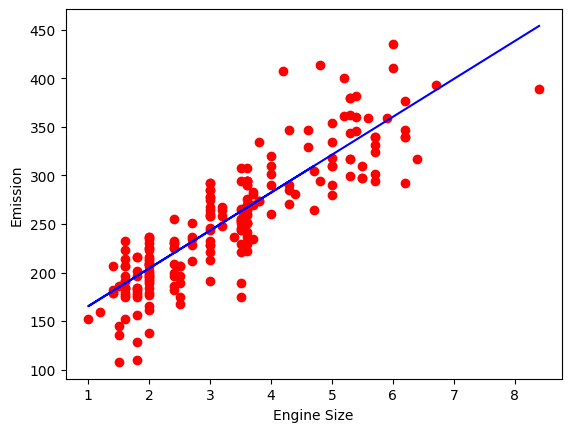

In [17]:
plt.scatter(X_test, y_test, color = "red")
plt.plot(X_test, regressor.coef_ * X_test + regressor.intercept_, '-r', color='blue')
plt.xlabel('Engine Size')
plt.ylabel("Emission")
plt.show()


Let's see the evaluation metrics if we train a regression model using the `FUELCONSUMPTION_COMB` feature.

We select the fuel consumption feature from the dataframe and split the data 80%/20% into training and testing sets. 
Using the same random state as previously so we can make an objective comparison to the previous training result.

In [18]:
X = cdf.FUELCONSUMPTION_COMB.to_numpy()

X_train2, X_test2, y_train2, y_test2 = train_test_split(X,y, test_size=0.2, random_state = 42)

#### Now we train a linear regression model using the training data we created.
We should transform the 1D feature into a 2D array as well. 

In [19]:
regr = linear_model.LinearRegression()
regr.fit(X_train2.reshape(-1, 1), y_train2)

LinearRegression()

We will use the model to make test predictions on the fuel consumption testing data. Then, calculate and print the Mean Squared Error of the test predictions

In [20]:
y_pred2 = regr.predict(X_test2.reshape(-1,1))
print("Mean squared error: %.2f" % mean_squared_error(y_test2, y_pred2))

Mean squared error: 797.43


Text(0, 0.5, 'Emission')

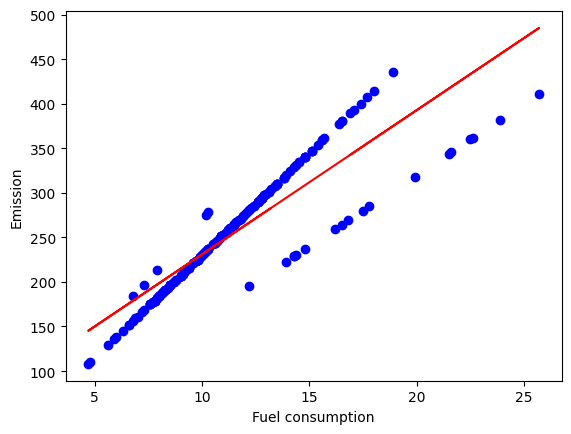

In [21]:
plt.scatter(X_test2, y_test2, color = 'blue')
plt.plot(X_test2, regr.coef_ * X_test2 + regr.intercept_, '-r')
plt.xlabel("Fuel consumption")
plt.ylabel("Emission")

# Multiple Linear Regression

- Now we will dive in an extension of simple liner regression which is **Multiple Liner Regression** 
- We will use the same dataset used for linear regression but this time, we will use 2 or more independent variables to estimate a dependent variable

In [22]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df2 = pdiddy.read_csv(url)
df2.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [23]:
df2 = df2.drop(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE',],axis=1)
df2.corr()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


When we look at the bottom row, which shows the correlation between each variable and the target, 'CO2EMISSIONS'. Each of these shows a fairly high level of correlation, each exceeding 85% in magnitude. Thus all of these features are good candidates. 

Next, examine the correlations of the distinct pairs. 'ENGINESIZE' and 'CYLINDERS' are highly correlated, but 'ENGINESIZE' is more correlated with the target, so we can drop 'CYLINDERS'. 

Similarly, each of the four fuel economy variables is highly correlated with each other. Since FUELCONSUMPTION_COMB_MPG is the most correlated with the target, we can drop the others: 'FUELCONSUMPTION_CITY,' 'FUELCONSUMPTION_HWY,' 'FUELCONSUMPTION_COMB.'

Notice that FUELCONSUMPTION_COMB and FUELCONSUMPTION_COMB_MPG are not perfectly correlated. They should be, though, because they measure the same property in different units. In practice, we would investigate why this is the case. We might find out that some or all of the data is not useable as is.


In [24]:
df2 = df2.drop(['CYLINDERS', 'FUELCONSUMPTION_CITY','FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB'], axis =1)
df2.head(6)

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,33,196
1,2.4,29,221
2,1.5,48,136
3,3.5,25,255
4,3.5,27,244
5,3.5,28,230


To help with selecting predictive features that are not redundant, consider the following scatter matrix, which shows the scatter plots for each pair of input features. The diagonal of the matrix shows each feature's histogram.

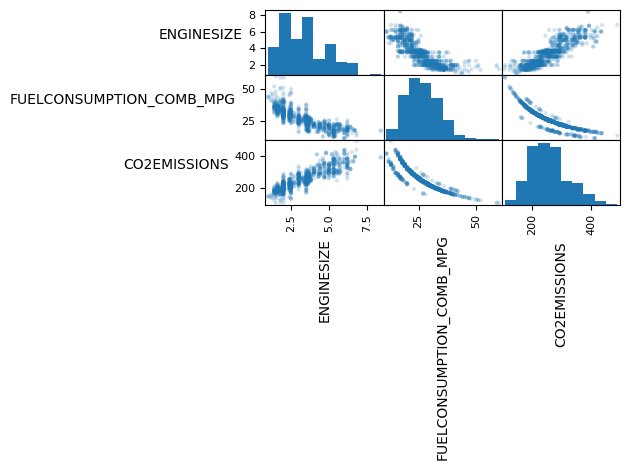

In [25]:
axes = pdiddy.plotting.scatter_matrix(df2, alpha=0.2)
#we will rotate axis labels so we can read them

for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

As we can see, the relationship between 'FUELCONSUMPTION_COMB_MPG' and 'CO2EMISSIONS' is non-linear. In addition, we can clearly see three different curves. This suggests exploring the categorical variables to see if they are able to explain these differences. Let's consider through modeling whether fuel economy explains some of the variances in the target as is.

### Extract the input features and labels from the data set
Extracting the required columns and converting the resulting dataframes to NumPy arrays.

In [26]:
X = df2.iloc[:,[0,1]].to_numpy()
y = df2.iloc[:,[2]].to_numpy()

### Preprocess selected features

We should standardize our input features so the model doesn't inadvertently favor any feature due to its magnitude.
The typical way to do this is to subtract the mean and divide by the standard deviation. Scikit-learn can do this for us :)

In [27]:
from sklearn import preprocessing

std_scaler = preprocessing.StandardScaler()
X_std = std_scaler.fit_transform(X)

## IMPORTANT:

In practice, if we want to properly evaluate our model, we should definitely not apply such operations to the entire dataset but to the train and test data separately. There's more to it than that.

In [28]:
pdiddy.DataFrame(X_std).describe().round(2)

,0,1
count,1067.00,1067.00
mean,0.00,-0.00
std,1.00,1.00
min,-1.66,-2.07
25%,-0.95,-0.73
50%,0.04,-0.06
75%,0.67,0.61
max,3.57,4.50


As we can see, a standardized variable has zero mean and a standard deviation of one.

### Create train and test datasets
Randomly split our data into train and test sets, using 80% of the dataset for training and reserving the remaining 20% for testing.

In [29]:
from sklearn.model_selection import train_test_split

X_train3, X_test3, y_train3, y_test3 = train_test_split(X_std,y, test_size= 0.2, random_state=42)

### Build a multiple linear regression model
Multiple and simple linear regression models can be implemented with exactly the same scikit-learn tools.

In [30]:
from sklearn import linear_model

#create a model object
regressor = linear_model.LinearRegression()

#train the model in the training data
regressor.fit(X_train3, y_train3)

#Print the coefficients
coef3_ = regressor.coef_
intercept3_ = regressor.intercept_

print('Coefficients: ', coef3_)
print('Intercept: ', intercept3_)

Coefficients:  [[ 25.27339614 -37.4381472 ]]
Intercept:  [256.29072488]


The Coefficients and Intercept parameters define the best-fit hyperplane to the data. Since there are only two variables, hence two parameters, the hyperplane is a plane. But this best-fit plane will look different in the original, unstandardized feature space. 

We can transform our model's parameters back to the original space prior to standardization as follows. This gives us a proper sense of what they mean in terms of our original input features. Without these adjustments, the model's outputs would be tied to an abstract, transformed space that doesn’t align with the actual independent variables and the real-world problem we’re solving.

In [31]:
#Let's get the standard scaler's mean and standard deviation parameters
means3_ = std_scaler.mean_
std_devs_3 = np.sqrt(std_scaler.var_)

#The least squares parameters can be calculated relative to the original, unstandardized feature space as:
coef_original = coef3_ / std_devs_3
intercept_original = intercept3_ - np.sum((means3_ * coef3_) / std_devs_3)

print ('Coefficients: ', coef_original)
print('intercept3_ :', intercept_original)

Coefficients:  [[17.8581369  -5.01502179]]
intercept3_ : [329.1363967]


We would expect that for the limiting case of zero ENGINESIZE and zero FUELCONSUMPTION_COMB_MPG, the resulting CO2 emissions should also be zero. This is inconsistent with the 'best fit' hyperplane, which has a non-zero intercept of 329 g/km. The answer must be that the target variable does not have a very strong linear relationship to the dependent variables, and/or the data has outliers that are biasing the result. Outliers can be handled in preprocessing, or by using regularization techniques. One or more of the variables might have a nonlinear relationship to the target. Or there may still be some colinearity amongst the input variables.

### Visualize model outputs
We can visualize the goodness-of-fit of the model to the training data by plotting the fitted plane over the data. 

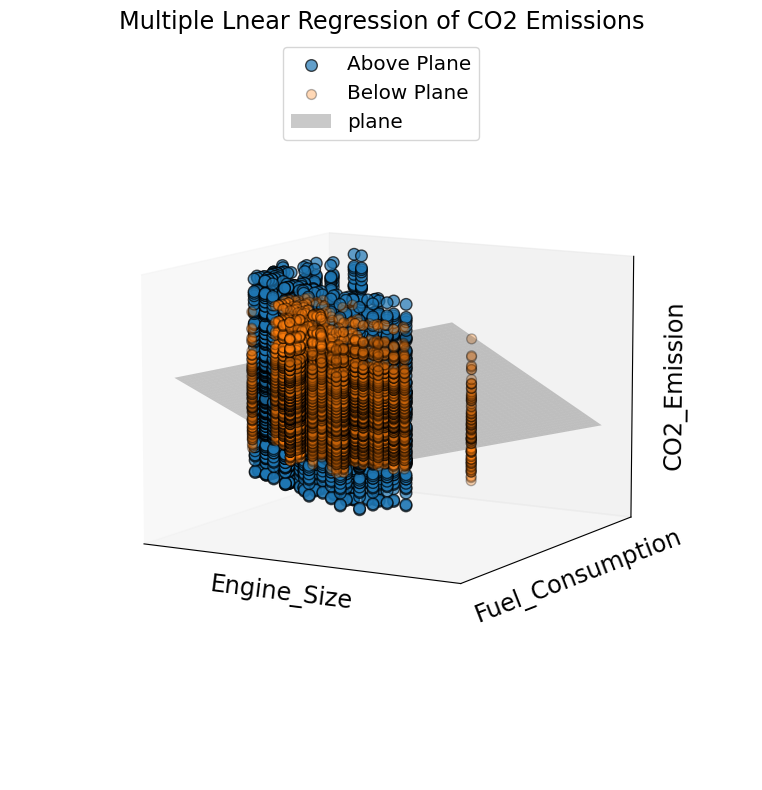

In [32]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

#We have to ensure that X1, X2 and y_test have compatible shapes for 3D plotting
X1 = X_test3[:, 0] if X_test3.ndim > 1 else X_test3
X2 = X_test3[:, 1] if X_test3.ndim > 1 else np.zeros_like(X1)

#Let's create a mesh grid for plotting the regssion plane
x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100),
                               np.linspace(X2.min(), X2.max(), 100))

y_surf = intercept3_ + coef3_[0,0] * x1_surf + coef3_[0,1] * x2_surf

#We will predict y values usinf trained regression model to compare with actual y_test3 for above/below plane colors
y_pred3 = regressor.predict(X_test3.reshape(-1,1)) if X_test3.ndim == 1 else regressor.predict(X_test3)
above_plane = y_test3 >= y_pred3
below_plane = y_test3 < y_pred3
above_plane = above_plane[:,0]
below_plane = below_plane[:,0]

#Plotting
fig = plt.figure(figsize=(20,8))
ax = fig.add_subplot(111, projection='3d')

#Plot the data points above and below the plane in different colors
ax.scatter(X1[above_plane], X2[above_plane], y_test3[above_plane], label='Above Plane', s=70, alpha=.7,ec='k')
ax.scatter(X1[below_plane], X2[below_plane], y_test3[below_plane], label='Below Plane', s=50,alpha=.3,ec='k')

#Let's plot the regression plane
ax.plot_surface(x1_surf, x2_surf, y_surf, color='k', alpha=0.21, label= 'plane')

#set view and labels

ax.view_init(elev=10)

ax.legend(fontsize='x-large', loc='upper center')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_box_aspect(None, zoom=0.75)
ax.set_xlabel('Engine_Size', fontsize = 'xx-large')
ax.set_ylabel('Fuel_Consumption', fontsize = 'xx-large')
ax.set_zlabel('CO2_Emission', fontsize = 'xx-large')
ax.set_title('Multiple Lnear Regression of CO2 Emissions', fontsize = 'xx-large')
plt.tight_layout()
plt.show()


While a 3D graph can be impressive and eye-catching but it is difficult to intercept, we can look at vertical slices of the 3D plot by plotting each variable separately as a best-fit line using thne corresponding regression parameters

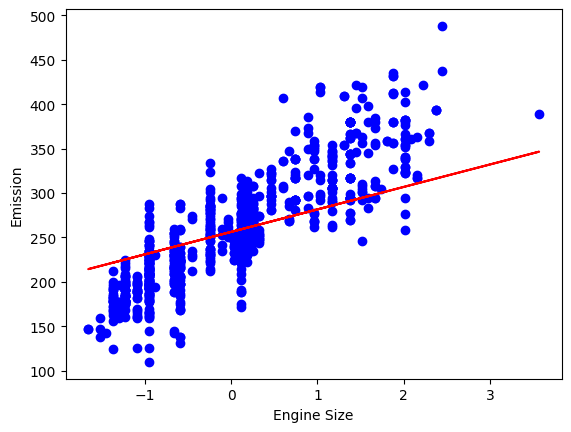

In [33]:
plt.scatter(X_train3[:,0], y_train3, color ='blue')
plt.plot(X_train3[:,0], coef3_[0,0] * X_train3[:,0] + intercept3_[0], '-r')
plt.xlabel("Engine Size")
plt.ylabel("Emission")
plt.show()

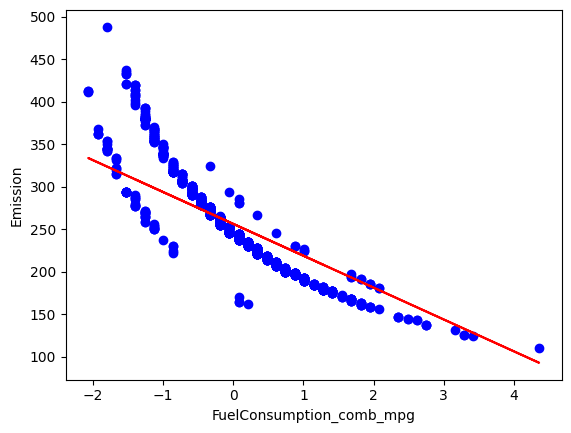

In [34]:
plt.scatter(X_train3[:,1], y_train3, color = 'blue')
plt.plot(X_train3[:,1], coef3_[0,1] * X_train3[:,1] + intercept3_[0], '-r')
plt.xlabel('FuelConsumption_comb_mpg')
plt.ylabel('Emission')
plt.show()

Evidently as expected, the solution is incredibly poor because the model is trying to fit a plane to a non-planar surface.

Let's determine and print the parameters for the best-fit linear regression line for CO2 Emission with respect to engine size

In [35]:
X_train4 = X_train3[:, 0]

regressor_4 = linear_model.LinearRegression()
regressor_4.fit(X_train4.reshape(-1,1), y_train3)
coef4_ = regressor_4.coef_
intercept4_ = regressor_4.intercept_

print('Coefficients: ', coef4_)
print('Intercepts: ', intercept4_)

Coefficients:  [[55.18408797]]
Intercepts:  [256.77183014]


Let's produce a scatterplot of CO2 emission against ENGINESIZE and include the best-fit regression line to the training data

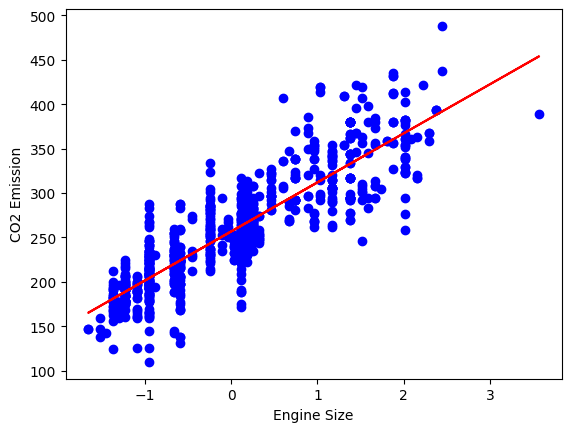

In [36]:
plt.scatter(X_train4, y_train3, color = 'blue')
plt.plot(X_train4, coef4_[0] * X_train4 + intercept4_, '-r')
plt.xlabel('Engine Size')
plt.ylabel('CO2 Emission')
plt.show()

Evidently, this simple linear regression model provides a much better fit of CO2 emissions on the trainning data than the multiple regresison model did. Let's see what its performance is on the test data.

Let's generate the same scatterplot and best-fit regression line, but now we will base the result on the test data set. We will study how the test result compares to the training result

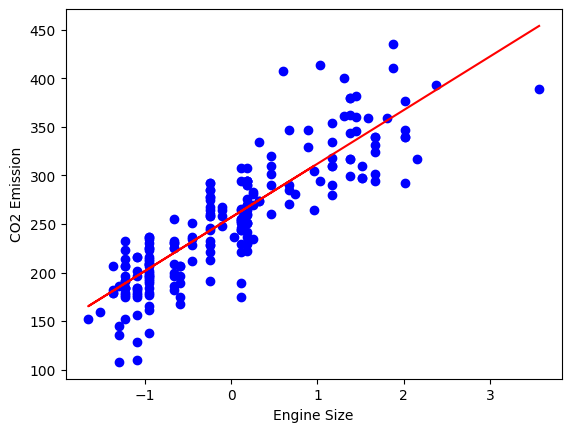

In [37]:
X_test4 = X_test3[:,0]
plt.scatter(X_test4, y_test3, color = 'blue')
plt.plot(X_test4, coef4_[0] * X_test4 + intercept4_, '-r')
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emission")
plt.show()

Let's repeat the same modeling but using FUELCONSUMPTION_COMB_MPG as the independent variable instead. We will display the model coefficients including the intercept

In [38]:
X_train5 = X_train3[:,1]
regressor_5 = linear_model.LinearRegression()
regressor_5.fit(X_train5.reshape(-1,1), y_train3)

coef5_ = regressor_5.coef_
intercept5_ = regressor_5.intercept_

print('Coefficents: ', coef5_)
print('Intercepts: ', intercept5_)

Coefficents:  [[-58.51827989]]
Intercepts:  [256.09392179]


Same as ENGINESIZE we will generate a scatter plot showing the results as before on the test data. we have to consider well the model fits, and what we might be able to do to improve it.

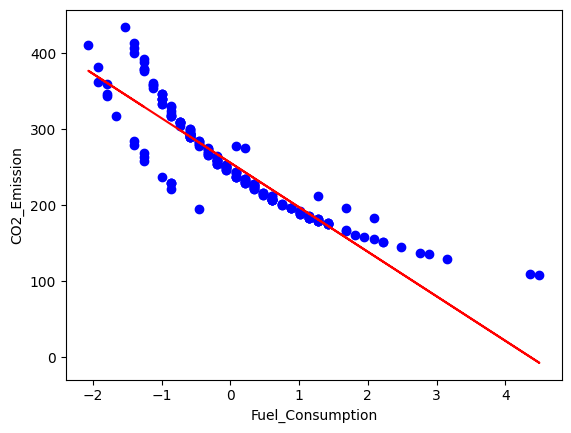

In [39]:
X_test5 = X_test3[:,1]
plt.scatter(X_test5, y_test3, color = 'blue')
plt.plot(X_test5, coef5_[0] * X_test5 + intercept5_, '-r')
plt.xlabel('Fuel_Consumption')
plt.ylabel("CO2_Emission")
plt.show()